### Installation des dépendances

Exécutez la commande suivante pour installer les dépendances à partir de la racine du repo:

```bash
uv sync --package ibm-runtime
```

Un environnement virtuel devrait être créé, il pourra être utilisé avec ce notebook.

### Références

Ce notebook est inspiré de la documentation sur la mitigation d'erreur, remplaçant la collecte des résultats par *expectation value* en *samples* : https://quantum.cloud.ibm.com/docs/en/tutorials/combine-error-mitigation-techniques

La section sur la simulation bruitée est tirée de la documentation de Qiskit Aer : https://qiskit.github.io/qiskit-aer/tutorials/2_device_noise_simulation.html

## 1. Construction d'un circuit quantique

Voici ci-dessous un circuit quantique à 10 qubits servant d'exmple. Construit à partir d'une structure de type `EfficientSU2`, ce gabarit est parfois utilisé en optimisation ou en chimie. Vous pouvez trouver plus d'informations sur ce circuit dans la [documentation de Qiskit - EfficientSU2](https://qiskit.org/documentation/stubs/qiskit.circuit.library.EfficientSU2.html).
Malgré son implémentation optimisée pour l'efficacité sur les appareils quantiques, on peut constater que, pour une seule occurrence du motif, le circuit contient un nombre de portes élémentaires relativement important.

In [149]:
import matplotlib.pyplot as plt
import numpy as np

from qiskit.circuit.library import efficient_su2, unitary_overlap
from qiskit.quantum_info import SparsePauliOp

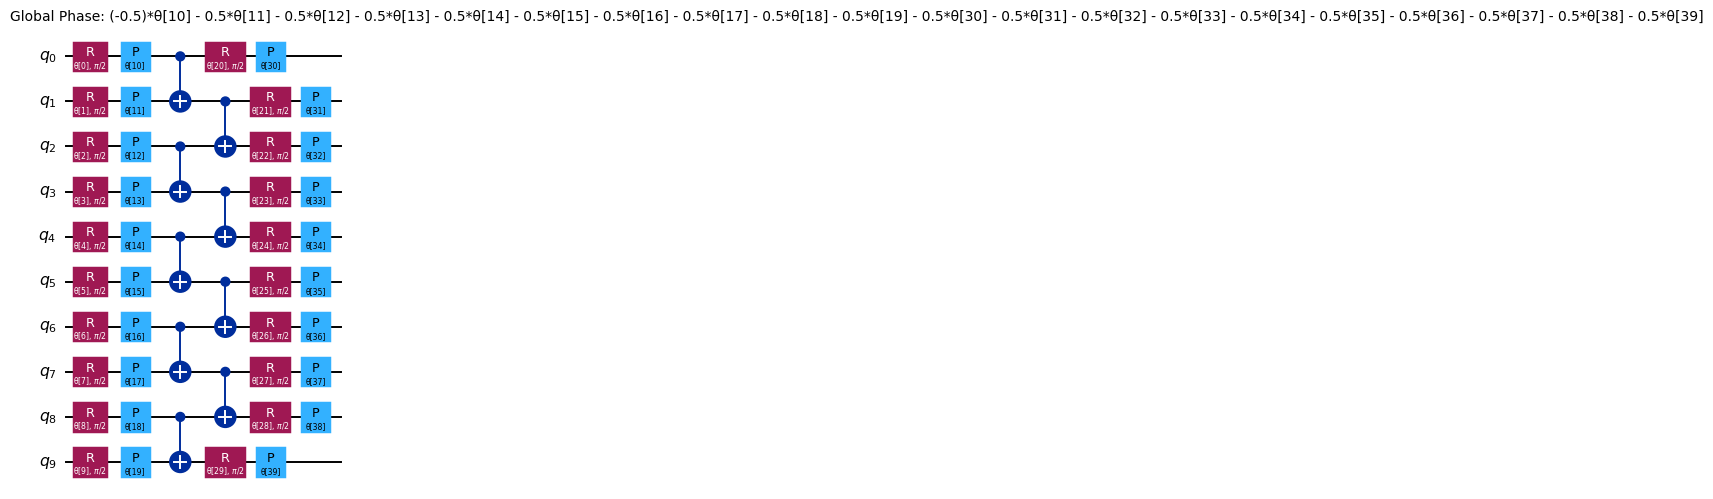

In [150]:
n_qubits = 10 # Nombre de qubits du circuit
reps = 1 # Nombre de répétitions du motif

circuit = efficient_su2(n_qubits, entanglement="pairwise", reps=reps)

circuit.decompose().draw("mpl", scale=0.7) # Circuit décomposé pour mieux voir les portes élémentaires

Une technique courante pour valider un résultat d'expérience, particulièrement dans le cas d'un circuit de grande taille, est d'utiliser un circuit miroir, ou *mirror circuit*. Cette technique, également appelée *compute-uncompute*, consiste à exécuter le circuit dans un ordre inverse après l'avoir exécuté dans l'ordre normal. En théorie, si le circuit est parfaitement implémenté et que les portes sont idéales, le circuit miroir devrait ramener l'état quantique à son état initial, ce qui permet de vérifier que les opérations ont été correctement appliquées.

Le circuit précédent peut prendre des paramètres d'entrée, que nous appliquerons aux deux versions du circuit (normal et miroir).

Vous utiliserez donc la variable `mirror_circuit` dans la suite du notebook pour tester vos exécutions.

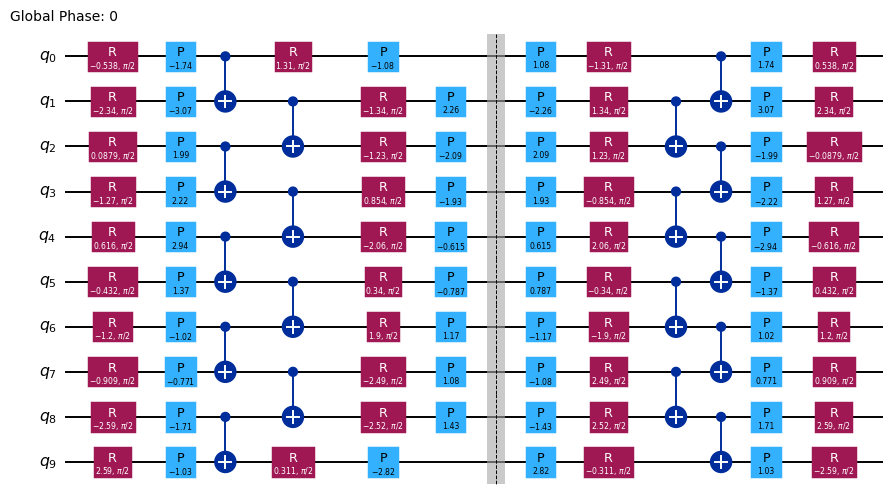

In [151]:
# Génération de paramètres aléatoires pour le circuit
rng = np.random.default_rng(67)
params = rng.uniform(-np.pi, np.pi, size=circuit.num_parameters)

# Assignation des paramètres au circuit
assigned_circuit = circuit.assign_parameters(params)

# Construction du circuit miroir, en insérant une barrière pour mettre en évidence l'axe de symétrie
mirror_circuit = unitary_overlap(assigned_circuit, assigned_circuit, insert_barrier=True)

mirror_circuit.decompose().draw("mpl", scale=0.7)

Nous allons maintenant ajouter la mesure en base Z à la fin du circuit miroir pour pouvoir récupérer les résultats de l'exécution. Ce serait un bon moment pour émettre une hypothèse sur ce que vous vous attendez à voir comme résultat de l'exécution du circuit miroir.

In [152]:
mirror_circuit.measure_all()

## 2. Exécution sur simulateur local

La prochaine section traite de l'exécution du circuit précédent sur un simulateur local en utilisant la bibliothèque `qiskit-aer` dont la documentation se trouve sur [Qiskit Aer](https://qiskit.github.io/qiskit-aer/).
Une documentation concernant la simulation de bruit est également dispobnible sur [Device backend noise model simulations](https://qiskit.github.io/qiskit-aer/tutorials/2_device_noise_simulation.html#).


### Définition du simulateur local et configuration du bruit

In [153]:
from qiskit_aer.primitives import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh # Modèle de bruit du même nom qu'un ordinateur quantique d'IBM, vous pouvez le changer pour le même modèle qui sera retournée par `.least_busy()` plus loin
from qiskit_ibm_runtime import SamplerOptions
from qiskit import transpile
from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [154]:
# Définition du simulateur local configuré avec le modèle de bruit d'une machine réelle d'IBM
backend = FakeMarrakesh()

simulator = SamplerV2.from_backend(backend)

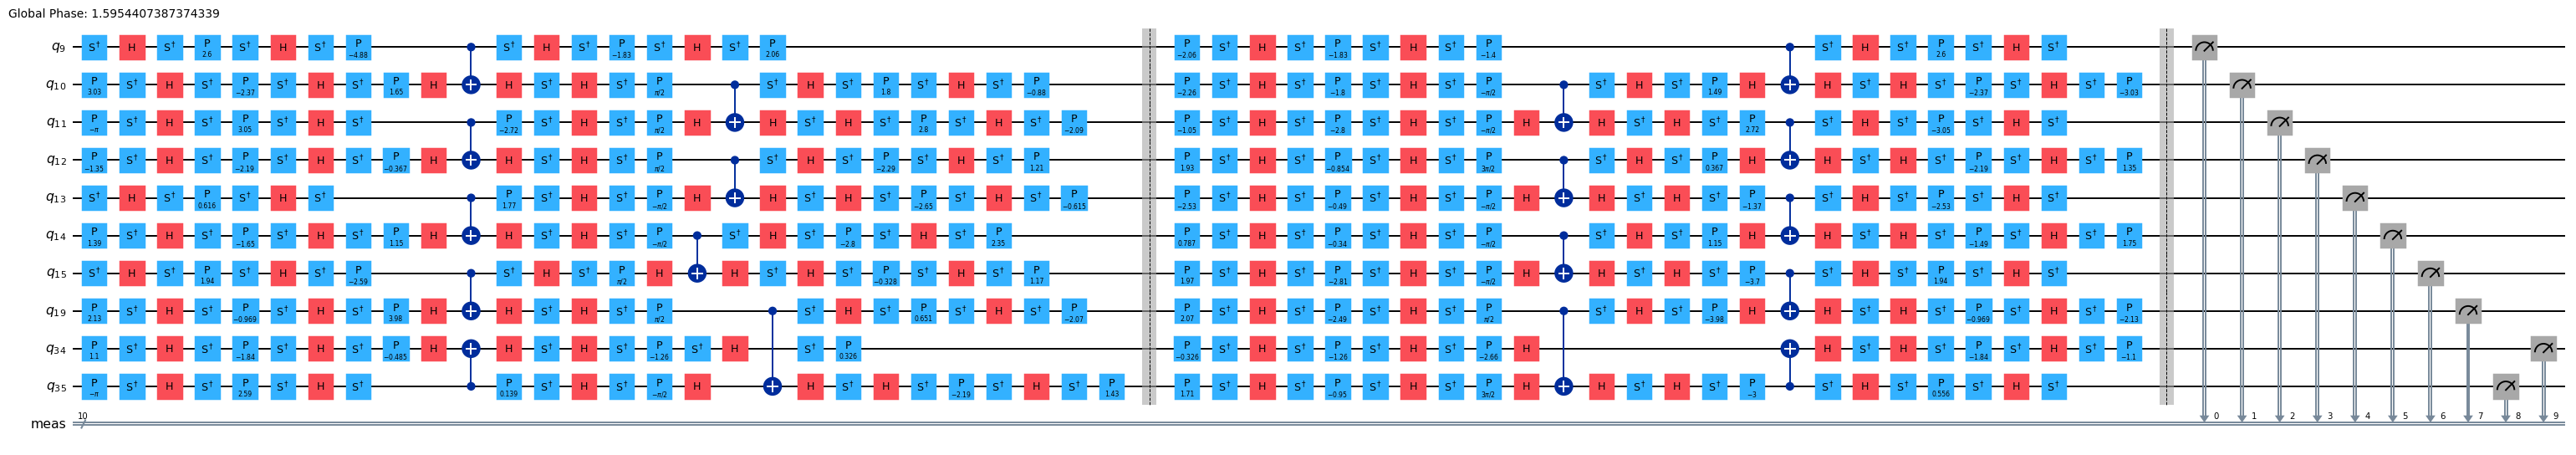

In [155]:
# Transpilation du circuit pour le simulateur
pass_manager : PassManager = generate_preset_pass_manager(
    optimization_level=3, backend=backend, seed_transpiler=67
)

isa_circuit = pass_manager.run(mirror_circuit)

isa_circuit.decompose().draw("mpl", scale=0.7, idle_wires=False, fold = -1)

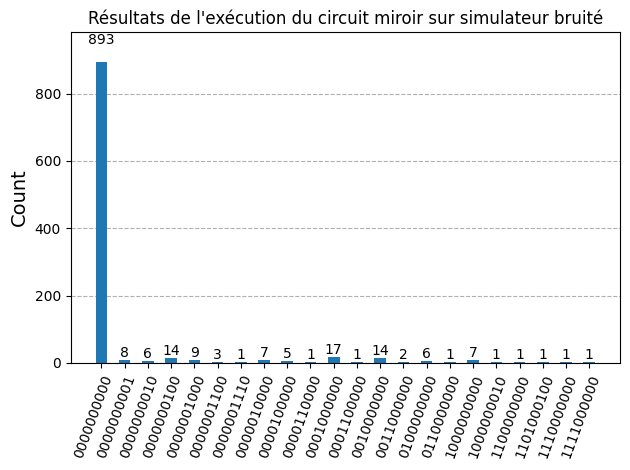

In [156]:
from qiskit.visualization import plot_histogram

# Exécution du circuit sur le simulateur
result = simulator.run(pubs=[(isa_circuit)], shots=1000).result()

counts = result[0].data.meas.get_counts()

plot_histogram(counts, title="Résultats de l'exécution du circuit miroir sur simulateur bruité")


## 3. Exécution sur un ordinateur quantique réel

Dans cette section, vous allez exécuter le même circuit sur un ordinateur quantique réel d'IBM en utilisant `qiskit-ibm-runtime` et vos informations de compte de la plateforme IBM Quantum.

Le club a déjà traité de la configuration dans [ce notebook sur Deepnote](https://deepnote.com/workspace/QuantumETS-bd6b11e4-0d15-4576-90e5-88412c5f674e/project/7-Executer-du-code-sur-un-ordinateur-quantique-86da04dd-0f4f-44c4-a6dc-3bf69b0f57fd/notebook/Notebook-1-b43399ed06384c5a95ac0f2afeca9f25?utm_source=share-modal&utm_medium=product-shared-content&utm_campaign=notebook&utm_content=86da04dd-0f4f-44c4-a6dc-3bf69b0f57fd).

In [157]:
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler import PassManager

In [158]:
# Il existe une façon de sauvegarder le compte https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/qiskit-runtime-service#save_account

service = QiskitRuntimeService(channel="ibm_cloud", token="jaTUi37yoJ73TsR5oN4vPAOWfXp8vgdxL2tG7NuNio_g", instance="Deepnote")
backend = service.least_busy(operational=True, simulator=False)
print(f"Backend choisi : {backend}")

qiskit_runtime_service._discover_account:WARNING:2026-05-29 16:34:50,260: Loading account with the given token. A saved account will not be used.


Backend choisi : <IBMBackend('ibm_marrakesh')>


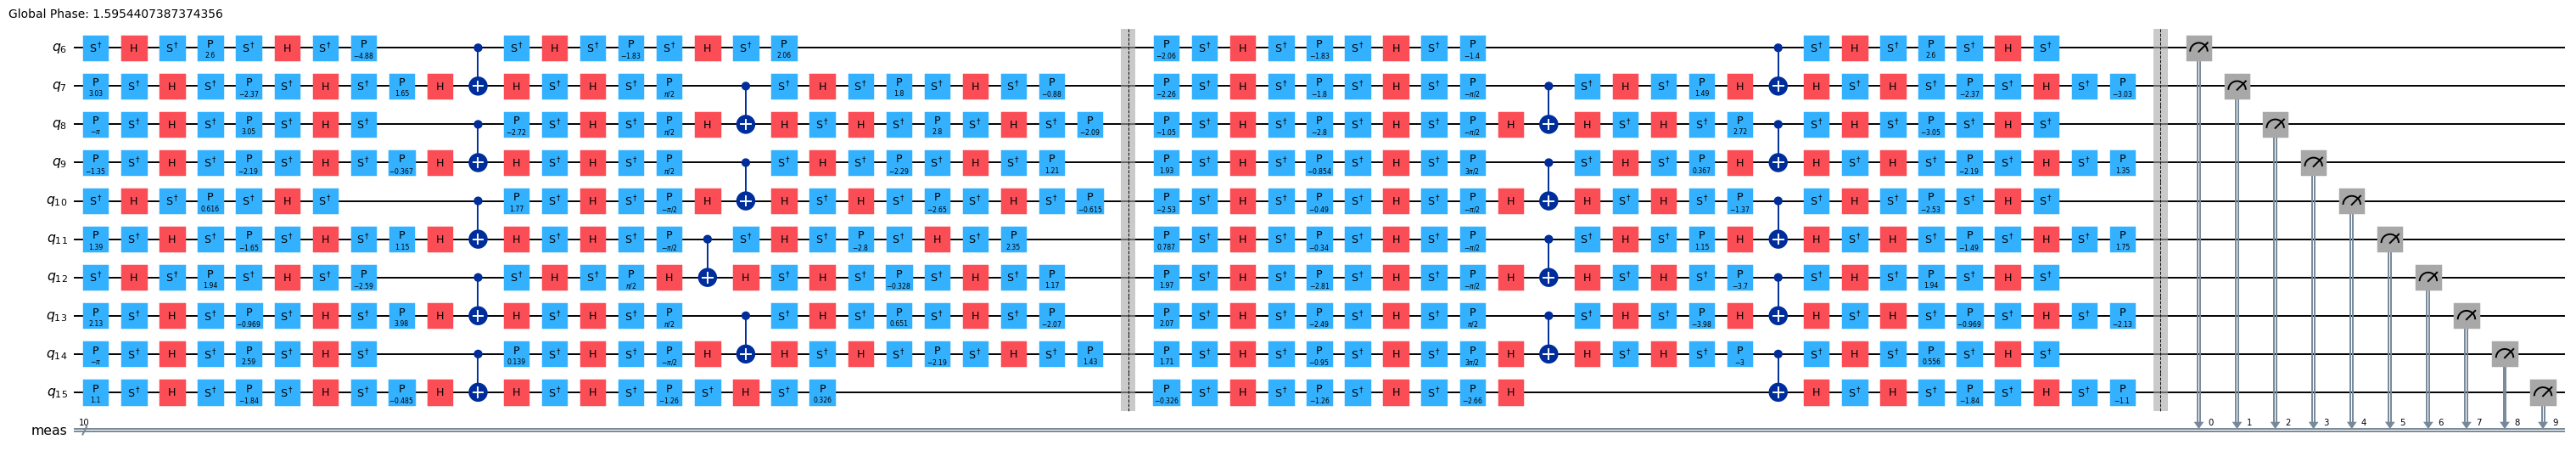

In [159]:
pass_manager : PassManager = generate_preset_pass_manager(
    optimization_level=3, backend=backend, seed_transpiler=67
)

isa_circuit = pass_manager.run(mirror_circuit)

isa_circuit.decompose().draw("mpl", scale=0.7, idle_wires=False, fold = -1)

### Exécution sans mitigation d'erreur



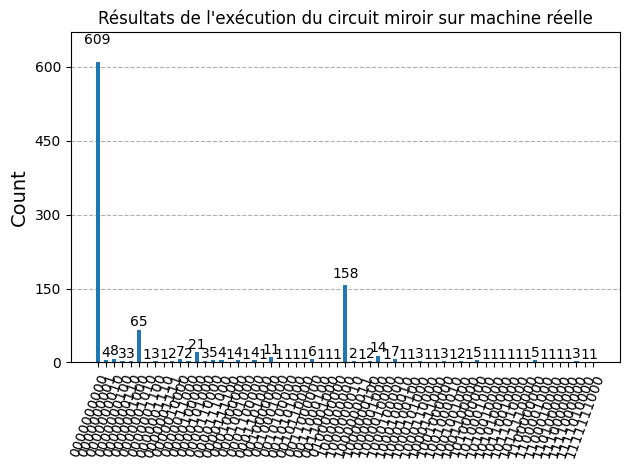

In [160]:
sampler = Sampler(mode=backend)

results = sampler.run([isa_circuit], shots=1000).result()

counts = results[0].data.meas.get_counts()

counts_0x000 = [counts.get("0000000000")]

plot_histogram(counts, title="Résultats de l'exécution du circuit miroir sur machine réelle")

### Exécution avec les techniques de mitigation d'erreur DC et Pauli Twirling

In [161]:
from qiskit_ibm_runtime import Batch

pub = (isa_circuit)

jobs = []

with Batch(backend=backend) as batch:
    sampler = Sampler(mode=batch)
    # Set number of shots
    sampler.options.default_shots = 1000

    # Add dynamical decoupling (DD)
    sampler.options.dynamical_decoupling.enable = True
    sampler.options.dynamical_decoupling.sequence_type = "XpXm"
    job1 = sampler.run([pub])
    jobs.append(job1)

    # Add gate twirling (DD + Gate Twirling)
    sampler.options.twirling.enable_gates = True
    sampler.options.twirling.num_randomizations = "auto"
    job2 = sampler.run([pub])
    jobs.append(job2)

In [162]:
# Lancement de toutes les jobs en parallèle
results = [job.result() for job in jobs]

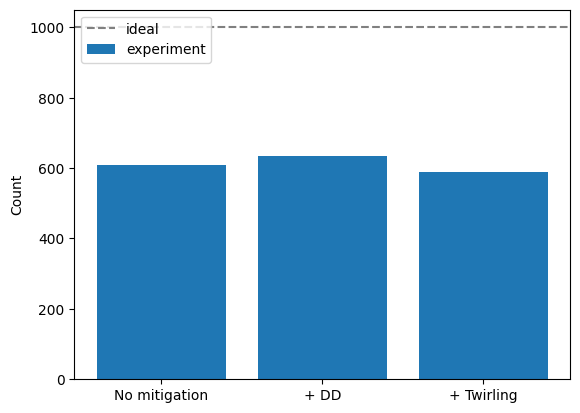

In [ ]:
# Déballage des résultats de chaque job (il n'y a qu'un seul résultat PUB dans chaque résultat de job)
pub_results = [result[0] for result in results]

# Déballage des comptes pour chaque résultat de PUB
counts = [pub_result.data.meas.get_counts() for pub_result in pub_results]

counts_0x000 += [count.get("0000000000") for count in counts]

# Tracer le compte pour la bitstring "000000000" (correspondant à l'état |000...0⟩), pour chaque technique de mitigation d'erreur
fig, ax = plt.subplots()
labels = ["No mitigation", "+ DD", "+ Twirling",]
ax.bar(
    range(len(labels)),
    counts_0x000,
    label="experiment",
)
ax.axhline(y=1000, color="gray", linestyle="--", label="ideal")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel("Count")
ax.legend(loc="upper left")

plt.show()